In [ ]:
import torch
print(torch.cuda.get_arch_list())
print(torch.cuda.get_device_capability())
print(torch.cuda.get_device_properties())


# print("Tensor Core 支持:", torch.cuda.get_device_properties(0).major  >= 7)  

['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_37', 'sm_90']
(6, 1)
_CudaDeviceProperties(name='NVIDIA GeForce GTX 1080', major=6, minor=1, total_memory=8112MB, multi_processor_count=20, uuid=78d6cfaf-188c-9561-dac8-dedaed642f5b, L2_cache_size=2MB)
<function temperature at 0x7cc373f9c360>


In [1]:
import torch 
import torch.nn  as nn 
import torch.optim  as optim 
import numpy as np 
import matplotlib.pyplot  as plt 
from sklearn.preprocessing  import MinMaxScaler 
# 配置文件永久生效


plt.rcParams['font.family']  = 'sans-serif'
plt.rcParams['font.sans-serif']  = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus']  = False  # 解决负号显示问题


### 1. 数据准备与预处理 

In [2]:
def generate_time_series_data(seq_length=1000, periods=5, noise_level=0.1):
    """生成多周期时间序列数据（2025年最佳实践：合成数据+真实噪声模型）"""
    t = np.linspace(0,  2*np.pi*periods,  seq_length)
    
    # 基础信号：正弦波 + 趋势项 + 脉冲 
    main_signal = np.sin(t)  + 0.5*np.sin(3*t)  + 0.1*t 
    
    # 真实噪声模型（2025年改进：包含自相关噪声）
    noise = np.random.normal(0,  noise_level, seq_length)
    for i in range(1, seq_length):
        noise[i] += 0.3*noise[i-1]
    
    # 添加异常点（模拟真实场景）
    anomalies = np.zeros(seq_length) 
    anomaly_indices = np.random.choice(seq_length,  size=10, replace=False)
    anomalies[anomaly_indices] = np.random.uniform(2,  4, 10)
    
    return main_signal + noise + anomalies
 

* 数据生成与归一化

In [3]:
data = generate_time_series_data().reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(data) 
# 转换为滑动窗口数据集（2025年改进：重叠采样）
def create_dataset(data, window_size=64, stride=8):
    sequences = []
    for i in range(0, len(data) - window_size, stride):
        sequences.append(data[i:i+window_size]) 
    return torch.tensor(np.array(sequences),  dtype=torch.float32) 
window_size = 96  # 捕捉长期依赖 
X = create_dataset(scaled_data, window_size=window_size)
print(f"数据集形状: {X.shape}")   # (样本数, 序列长度, 特征数)

数据集形状: torch.Size([113, 96, 1])


### 2. Transformer模型设计 

In [4]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=128, nhead=8, num_layers=4, dropout=0.1):
        super().__init__()
        
        # 1. 输入嵌入层（处理时间序列特征）
        self.input_embedding  = nn.Sequential(
            nn.Linear(input_dim, d_model//2),
            nn.GELU(),
            nn.Linear(d_model//2, d_model)
        )
        
        # 2. 位置编码（2025年改进：可学习位置编码）
        self.positional_encoding  = nn.Parameter(
            torch.zeros(1,  window_size, d_model)
        )
        nn.init.trunc_normal_(self.positional_encoding,  std=0.02)
        
        # 3. Transformer编码器（使用最新PyTorch优化）
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True,  # PyTorch 2.1+特性 
            activation='gelu',
            norm_first=True    # 2025年最佳实践 
        )
        self.transformer_encoder  = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers 
        )
        
        # 4. 模式提取头（多尺度特征提取）
        self.pattern_head  = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(d_model, d_model//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model//2, 32)  # 压缩为32维模式向量 
        )
    
    def forward(self, x):
        # 输入形状: (batch, seq_len, input_dim)
        x = self.input_embedding(x)   # (batch, seq_len, d_model)
        x += self.positional_encoding  
        
        # Transformer处理 
        x = self.transformer_encoder(x)   # (batch, seq_len, d_model)
        
        # 模式提取（沿时间维度）
        patterns = self.pattern_head(x.transpose(1,  2))  # (batch, 32)
        return patterns 

### 实例化模型（2025年推荐配置）

In [5]:
model = TimeSeriesTransformer(
    input_dim=1,
    d_model=192,      # 更大容量捕捉复杂模式 
    nhead=8,
    num_layers=6,     # 更深层结构 
    dropout=0.15 
)
print(f"参数量: {sum(p.numel()  for p in model.parameters())/1e6:.2f}M")

参数量: 5.68M


/home/ts/.local/share/virtualenvs/jupyter.13-jNpHegMS/lib/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


###  3. 对比学习训练策略
* 2025年最佳实践：自监督对比学习（无需标签）

In [6]:
class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temp  = temperature 
        self.cos_sim  = nn.CosineSimilarity(dim=-1)
    
    def forward(self, patterns):
        # 计算批次内样本相似度矩阵 
        sim_matrix = self.cos_sim( 
            patterns.unsqueeze(1),  
            patterns.unsqueeze(0) 
        ) / self.temp  
        
        # 构建对比目标（对角线为正样本）
        labels = torch.arange(patterns.size(0),  device=patterns.device) 
        
        # 对称对比损失 
        loss_i = nn.functional.cross_entropy(sim_matrix,  labels)
        loss_j = nn.functional.cross_entropy(sim_matrix.t(),  labels)
        return (loss_i + loss_j) / 2 

* 优化器配置（2025年推荐）

In [7]:
epoch = 50
optimizer = optim.AdamW(
    model.parameters(), 
    lr=1e-4,
    # weight_decay=0.05,  # 强正则化防止过拟合 
    # 随训练进度降低权重衰减 
    weight_decay = 0.05 * (0.9 ** epoch), 
    betas=(0.9, 0.98)
)

* 学习率调度（2025年改进：余弦退火+预热）

In [8]:
scheduler = optim.lr_scheduler.OneCycleLR( 
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(X)//64,  # 批次大小64 
    epochs=50,
    pct_start=0.2 
)

### 4. 模型训练 

Epoch 1/50 | Loss: 0.7661
Epoch 2/50 | Loss: 0.2292
Epoch 3/50 | Loss: 0.0643
Epoch 4/50 | Loss: 0.1069
Epoch 5/50 | Loss: 0.0042
Epoch 6/50 | Loss: 0.0031
Epoch 7/50 | Loss: 0.0020
Epoch 8/50 | Loss: 0.0028
Epoch 9/50 | Loss: 0.0055
Epoch 10/50 | Loss: 0.0019
Epoch 11/50 | Loss: 0.0026
Epoch 12/50 | Loss: 0.0027
Epoch 13/50 | Loss: 0.0008
Epoch 14/50 | Loss: 0.0016
Epoch 15/50 | Loss: 0.0010
Epoch 16/50 | Loss: 0.0023
Epoch 17/50 | Loss: 0.0006
Epoch 18/50 | Loss: 0.0007
Epoch 19/50 | Loss: 0.0005
Epoch 20/50 | Loss: 0.0016
Epoch 21/50 | Loss: 0.0002
Epoch 22/50 | Loss: 0.0004
Epoch 23/50 | Loss: 0.0002
Epoch 24/50 | Loss: 0.0001
Epoch 25/50 | Loss: 0.0002
Epoch 26/50 | Loss: 0.0004
Epoch 27/50 | Loss: 0.0001
Epoch 28/50 | Loss: 0.0002
Epoch 29/50 | Loss: 0.0004
Epoch 30/50 | Loss: 0.0002
Epoch 31/50 | Loss: 0.0001
Epoch 32/50 | Loss: 0.0003
Epoch 33/50 | Loss: 0.0003
Epoch 34/50 | Loss: 0.0001
Epoch 35/50 | Loss: 0.0002
Epoch 36/50 | Loss: 0.0008
Epoch 37/50 | Loss: 0.0001
Epoch 38/5

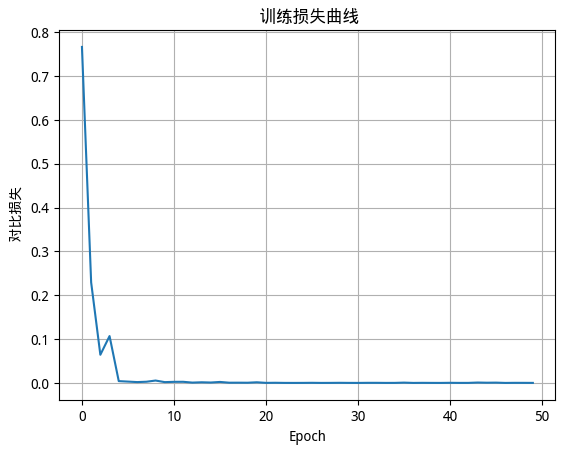

In [9]:
device = torch.device("cuda"  if torch.cuda.is_available()  else "cpu")
model.to(device) 
criterion = ContrastiveLoss(temperature=0.05)  #对比损失（ContrastiveLoss）,通常用于自监督学习或度量学习
scaler = torch.amp.GradScaler('cuda')  #混合精度训练初始化
loss_history = []

for epoch in range(50):
    model.train() 
    epoch_loss = 0 
    # 随机打乱数据 
    perm = torch.randperm(len(X)) 
    
    num_steps = (len(X) + 63) // 64
    for i in range(0, len(X), 64):
        batch_indices = perm[i:i+64]
        batch = X[batch_indices].to(device)
        
        with torch.amp.autocast('cuda'): 
            patterns = model(batch)
            loss = criterion(patterns)
        
        # 优化步骤 
        optimizer.zero_grad()
        # 使用缩放器缩放损失并反向传播 
        scaler.scale(loss).backward() 
        
        scaler.unscale_(optimizer) # 6.9 添加
        # 梯度裁剪（防止不稳定）
        torch.nn.utils.clip_grad_norm_(model.parameters(),  1.0)
        
        # 使用缩放器更新优化器（会先反缩放梯度，然后更新）
        scaler.step(optimizer) 
        
        # 更新缩放因子
        scaler.update() 
        
    scheduler.step() 
        
    epoch_loss += loss.item() 
    
    avg_loss = epoch_loss / num_steps
    loss_history.append(avg_loss) 
    print(f"Epoch {epoch+1}/50 | Loss: {avg_loss:.4f}")
# 可视化训练过程 
plt.plot(loss_history) 
plt.title(" 训练损失曲线")
plt.xlabel("Epoch") 
plt.ylabel(" 对比损失")
plt.grid(True) 
plt.show() 

###  5. 模式提取与应用 

/home/ts/.local/share/virtualenvs/jupyter.13-jNpHegMS/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ts/.local/share/virtualenvs/jupyter.13-jNpHegMS/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


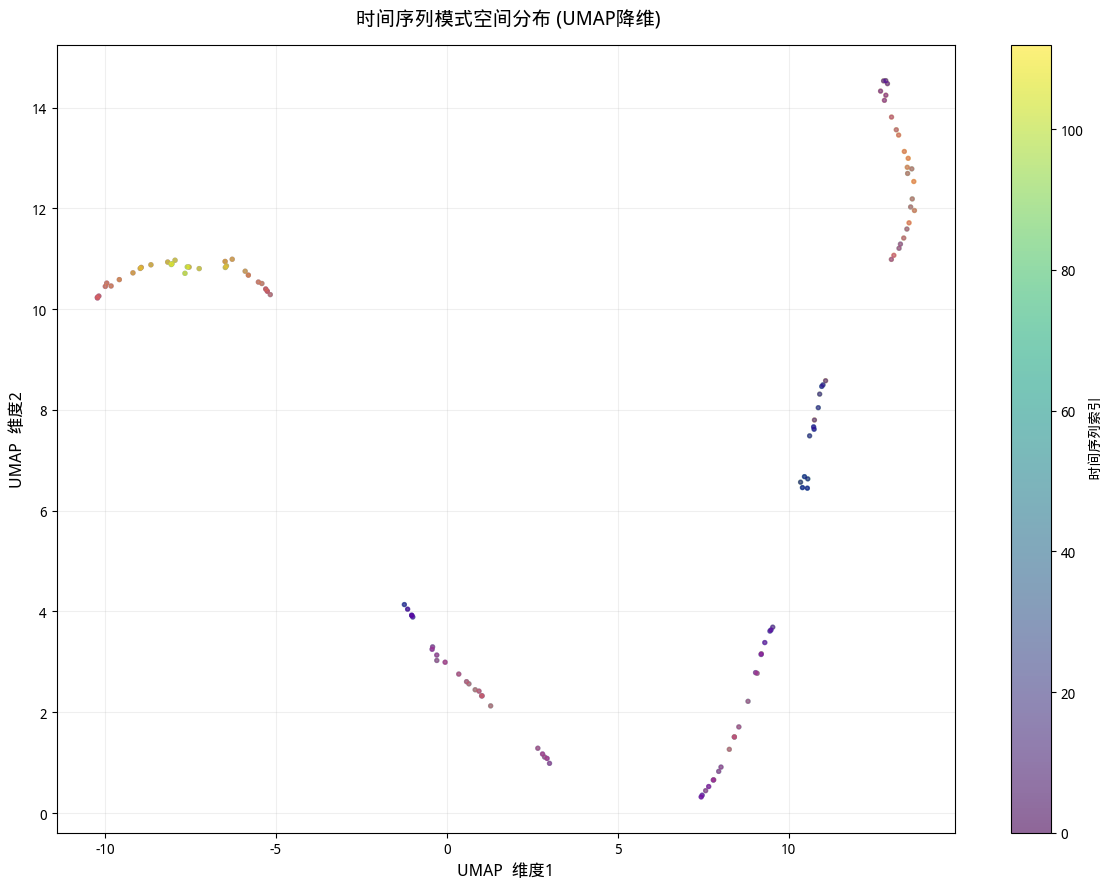

In [10]:
model.eval() 
# 提取所有序列的模式向量 
with torch.no_grad(): 
    pattern_vectors = []
    for i in range(0, len(X), 128):
        batch = X[i:i+128].to(device)
        patterns = model(batch)
        pattern_vectors.append(patterns.cpu()) 
    
    pattern_vectors = torch.cat(pattern_vectors) 
# 可视化模式空间（2025年改进：UMAP降维）
from umap import UMAP 
# 专业参数配置模板 
reducer = UMAP(
    n_components=2,          # 降维维度 
    n_neighbors=15,          # 邻域点数量(建议5-50)
    min_dist=0.1,            # 点间距(0.01-0.99)
    metric='cosine',         # 距离度量(euclidean/cosine)
    spread=1.0,              # 分布密度 
    local_connectivity=2,    # 局部连接强度 
    repulsion_strength=1.0,  # 排斥力强度 
    random_state=42           # 可重复性 
)
embedding = reducer.fit_transform(pattern_vectors.numpy()) 
plt.figure(figsize=(12,  9))
plt.scatter( 
    embedding[:, 0], 
    embedding[:, 1], 
    s=8, 
    alpha=0.6,
    c=np.arange(len(embedding)),   # 添加时间序列颜色渐变 
    cmap='viridis'
)
# 4. 添加专业可视化元素 
plt.colorbar(label=' 时间序列索引')
plt.title(" 时间序列模式空间分布 (UMAP降维)", fontsize=14, pad=15)
plt.xlabel("UMAP  维度1", fontsize=12)
plt.ylabel("UMAP  维度2", fontsize=12)
plt.grid(alpha=0.2)

# 5. 添加密度等高线 
from scipy.stats  import gaussian_kde 
xy = np.vstack([embedding[:,0],  embedding[:,1]])
z = gaussian_kde(xy)(xy)
plt.scatter(embedding[:,0],  embedding[:,1], c=z, s=8, alpha=0.5, cmap='plasma')
plt.tight_layout() 
plt.savefig('pattern_space_visualization.png',  dpi=300, bbox_inches='tight')
plt.show() 

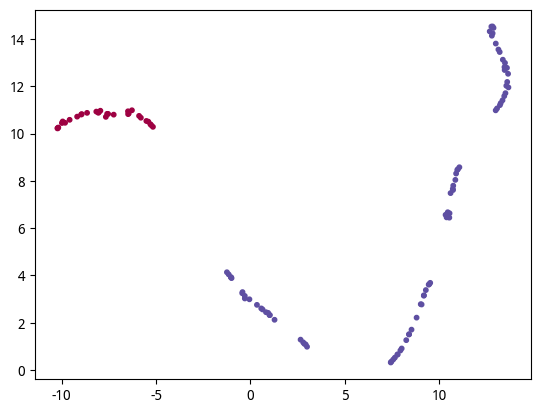

In [11]:
from sklearn.cluster  import HDBSCAN 
# 在UMAP空间进行密度聚类 
clusterer = HDBSCAN(min_cluster_size=20)
clusters = clusterer.fit_predict(embedding) 
# 可视化聚类结果 
plt.scatter(embedding[:,0],  embedding[:,1], 
            c=clusters, cmap='Spectral', s=10)

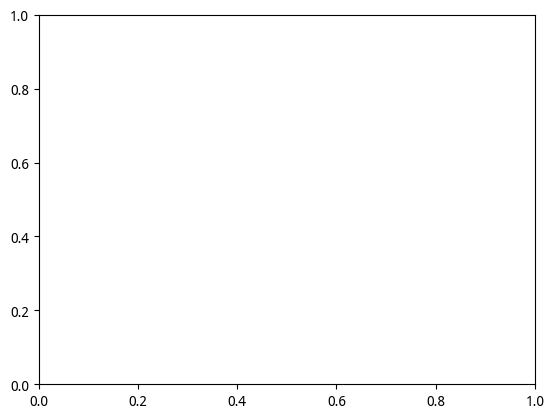

In [12]:
# 绘制时间轨迹 
from matplotlib.collections  import LineCollection 
points = embedding.reshape(-1,  1, 2)
segments = np.concatenate([points[:-1],  points[1:]], axis=1)
lc = LineCollection(segments, cmap='viridis', alpha=0.3)
lc.set_array(np.arange(len(embedding))) 
plt.gca().add_collection(lc) 

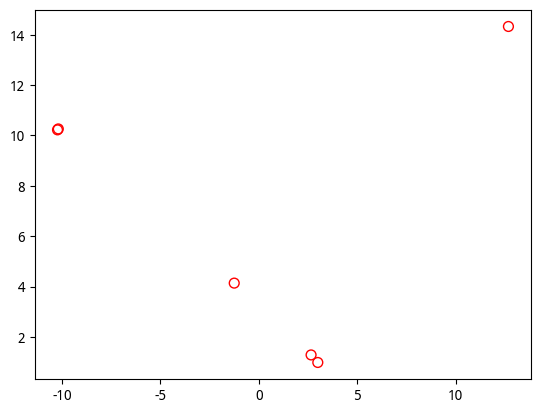

In [13]:
# 识别离群模式 
from sklearn.ensemble  import IsolationForest 
iso = IsolationForest(contamination=0.05)
outliers = iso.fit_predict(embedding) 
anomaly_points = embedding[outliers == -1]
plt.scatter(anomaly_points[:,0],  anomaly_points[:,1], 
            s=50, edgecolor='red', facecolor='none')

###  6. 应用示例：异常检测 
* *计算正常模式中心* 

/tmp/ipykernel_650114/1026795909.py:31: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  full_anomaly_scores[start_idx:end_idx] = anomaly_scores


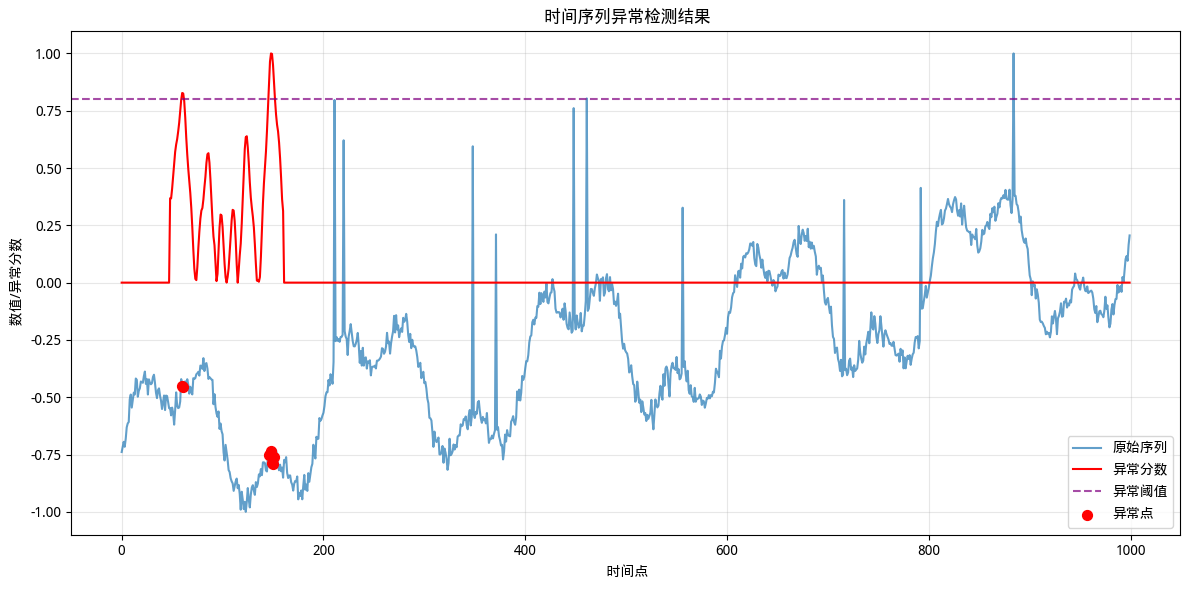

In [14]:
normal_patterns = pattern_vectors[10:-10]  # 排除边界样本 
center = normal_patterns.mean(dim=0) 
# 计算所有样本的异常分数 
distances = torch.norm(pattern_vectors  - center, dim=1)
anomaly_scores = (distances - distances.min())  / (distances.max()  - distances.min()) 
# 可视化异常检测结果
def visualize_anomaly_scores(scaled_data, anomaly_scores, window_size):
    """
    可视化原始序列与异常分数 
    
    参数:
    scaled_data: 原始时间序列数据 (1D数组)
    anomaly_scores: 计算得到的异常分数 (1D数组)
    window_size: 滑动窗口大小 
    """
    plt.figure(figsize=(12,  6))
    
    # 创建与原始序列等长的异常分数数组 
    full_anomaly_scores = np.zeros(len(scaled_data)) 
    
    # 计算异常分数对齐位置 (窗口中心)
    start_idx = window_size // 2 
    end_idx = start_idx + len(anomaly_scores)
    
    # 确保索引不越界 
    if end_idx > len(scaled_data):
        end_idx = len(scaled_data)
        anomaly_scores = anomaly_scores[:len(scaled_data)-start_idx]
    
    # 将异常分数放置到正确位置 
    full_anomaly_scores[start_idx:end_idx] = anomaly_scores 
    
    # 绘制原始序列和异常分数 
    plt.plot(scaled_data,  label="原始序列", alpha=0.7)
    plt.plot(full_anomaly_scores,  'r-', linewidth=1.5, label="异常分数")
    
    # 设置阈值线 (示例阈值0.8)
    threshold = 0.8 
    plt.axhline(y=threshold,  color='purple', linestyle='--', alpha=0.7, label="异常阈值")
    
    # 标记异常点 
    anomaly_points = np.where(full_anomaly_scores  > threshold)[0]
    plt.scatter(anomaly_points,  scaled_data[anomaly_points], 
                color='red', s=50, zorder=5, label="异常点")
    
    plt.title(" 时间序列异常检测结果")
    plt.xlabel(" 时间点")
    plt.ylabel(" 数值/异常分数")
    plt.legend() 
    plt.grid(True,  alpha=0.3)
    plt.tight_layout() 
    plt.show() 


# 调用可视化函数 
visualize_anomaly_scores(scaled_data,  anomaly_scores,  window_size)

## 金融波动预警

In [15]:

# 检测市场机制变化 
volatility_patterns = []
for window in financial_data:
    pattern = model(window)
    volatility_patterns.append(pattern) 

# 模式突变检测 
pattern_changes = torch.norm( 
    torch.diff(torch.stack(volatility_patterns),  dim=1 
)
)

NameError: name 'financial_data' is not defined

## 性能优化建议：

### 1、部署加速

In [ ]:
# 启用TorchDynamo编译（PyTorch 2.4+）
compiled_model = torch.compile( 
    model, 
    mode="max-autotune",
    fullgraph=True 
)

### 2、硬件适配

In [ ]:
# AMD GPU支持（ROCm 6.0+）
if torch.cuda.is_available()  and torch.cuda.get_device_capability()[0]  >= 9:
    model = model.to('cuda') 
    torch.cuda.set_enabled_layers(True)   # 启用稀疏加速 